# Notebook A of line ratios from saved maps from the PZ cube

This is from the splitting up of ZZ-01-01-more-line-ratios.ipynb.  It includes calculation of the reddening map

In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from mpdaf.obj import Image
import regions
import sys
import pandas as pd
import cmasher as cmr
import pyneb as pn

sns.set_context("talk")
sns.set_color_codes()

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/mpdaf/version.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Path to the root of this repo

In [2]:
ROOT = Path.cwd().parent.parent

In [3]:
mapspath = ROOT / "data/n346-bow-lines/refined"

In [4]:
def get_image(lineid, combo="P-007", ext="SUM"):
    im = Image(str(mapspath / f"map-{lineid}-{combo}.fits"), ext=ext)
    im.data = im.data.astype(float)
    return im


def get_image_raw(lineid, variant="csub", channel="ABC"):
    p = ROOT / "data" / "n346-bow-lines" / f"maps-n346-PZ-2pass-{variant}-007"
    candidates = list(p.glob(f"**/*-{lineid}-{channel}.fits"))
    assert candidates
    imfile = candidates[0]
    im = Image(str(imfile))
    im.data = im.data.astype(float)
    return im

## Calculate reddening from Balmer decrement

In [5]:
# Load the Hα and Hβ maps
imha = get_image_raw("h-i-6562-79")
imhb = get_image_raw("h-i-4861-32")

### Look at the raw Hα/Hβ ratio:

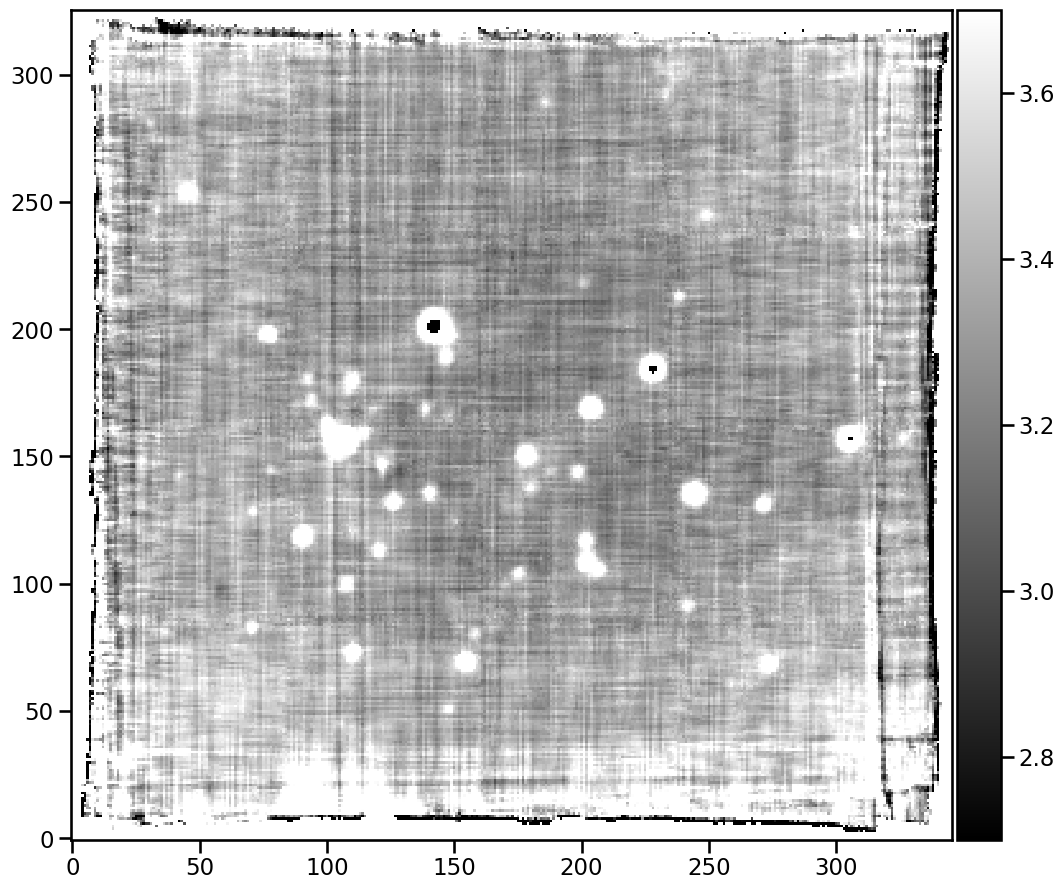

In [6]:
fig, ax = plt.subplots(figsize=(12, 12))
(imha / imhb).plot(vmin=2.7, vmax=3.7, cmap="gray", colorbar="v")

So we see very little structure there, compared with in the ESO pipeline cube case.  In priniciple, lighter means more extinction.  There might be a hint of this at the bottom of the image, where we see possible signs of the foreground filament.

But in other parts, we just see the stars (which have a different ratio because of photospheric absorption)

### PyNeb calculation of intrinsic Balmer decrement

In [7]:
hi = pn.RecAtom("H", 1)

Calculate the theoretical Balmer decrement from PyNeb. Density and temperature from Valerdi:2019a

In [8]:
tem, den = 12500, 100
R0 = hi.getEmissivity(tem, den, wave=6563) / hi.getEmissivity(tem, den, wave=4861)
R0

2.8205128205128207

### Look at correlation between Hα and Hβ in the faint limit

To make thinks easier, I multiply the Hb values by R0 so we have a square plot.  I zoom in on the faint parts:

In [9]:
imax = 100000
m = imha.data < imax
m = m & (R0 * imhb.data < imax)
m = m & ~imha.mask & ~imhb.mask
df = pd.DataFrame(
    {
        "ha": imha.data[m],
        "hb": R0 * imhb.data[m],
    }
)

Text(0.5, 0.98, 'Correlation between Ha and Hb brightness')

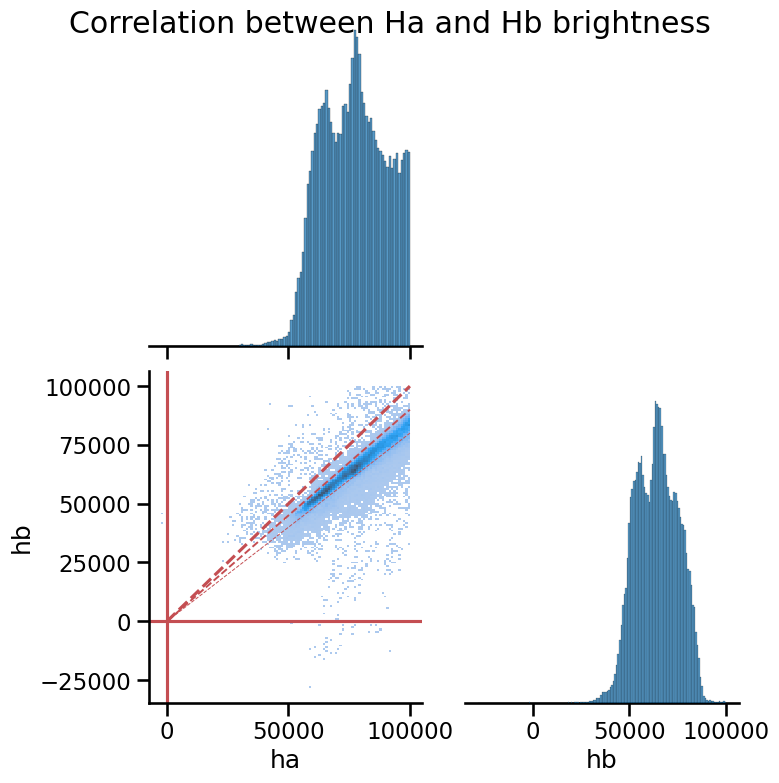

In [10]:
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)
g.axes[1, 0].axvline(0.0, color="r")
g.axes[1, 0].axhline(0.0, color="r")
g.axes[1, 0].plot([0, imax], [0, imax], "--", color="r")
g.axes[1, 0].plot([0, imax], [0, 0.9 * imax], "--", color="r", linewidth=1.4)
g.axes[1, 0].plot([0, imax], [0, 0.8 * imax], "--", color="r", linewidth=0.7)
g.fig.suptitle("Correlation between Ha and Hb brightness")

So, the slope is not unity, meaning the extinction is not zero.  But the intercept is zero, which is great. So nothing more to do,

Now define some regions to take averages

In [11]:
boxes = {
    "sw filament": regions.RegionBoundingBox(
        iymin=20,
        iymax=40,
        ixmin=200,
        ixmax=310,
    ),
    "bow shock": regions.RegionBoundingBox(
        iymin=165,
        iymax=205,
        ixmin=240,
        ixmax=290,
    ),
    "w filament": regions.RegionBoundingBox(
        iymin=100,
        iymax=130,
        ixmin=25,
        ixmax=55,
    ),
    "c filament": regions.RegionBoundingBox(
        iymin=195,
        iymax=210,
        ixmin=155,
        ixmax=195,
    ),
}

Plot on a better scale and show the regions:

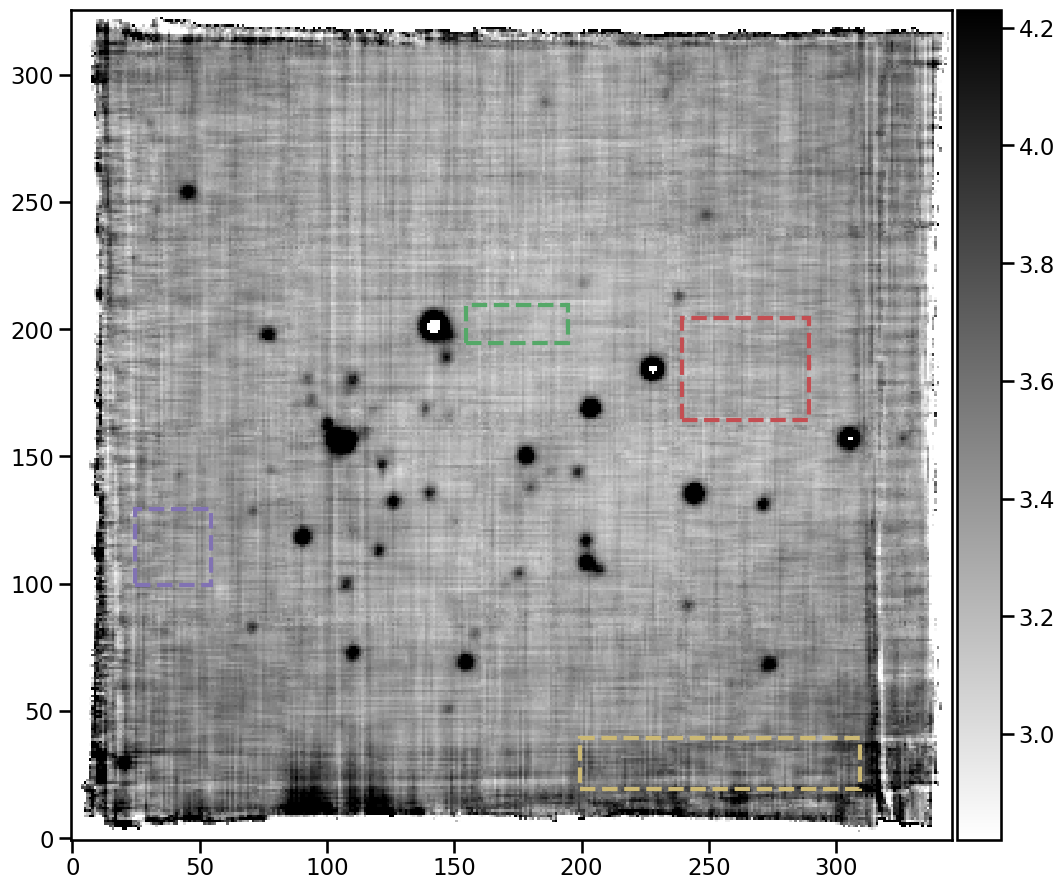

In [12]:
fig, ax = plt.subplots(figsize=(12, 12))
(imha / (imhb)).plot(
    vmin=R0,
    vmax=1.5 * R0,
    scale="linear",
    cmap="gray_r",
    colorbar="v",
)

for box, c in zip(boxes.values(), "yrmgc"):
    box.plot(
        ax=ax,
        lw=3,
        edgecolor=c,
        linestyle="dashed",
        #        facecolor=(1.0, 1.0, 1.0, 0.4),
        fill=False,
    )

We can see some very high extinction at in the S filaments.  And some small increase in extinction in the main diagonal filament.  This is probably limited having foreground emission to some extent.

Look at average values in the sample boxes

In [13]:
for label, box in boxes.items():
    (yslice, xslice), _ = box.get_overlap_slices(imha.shape)
    ha = np.median(imha[yslice, xslice].data.data)
    hb = np.median(imhb[yslice, xslice].data.data)
    print(f"{label}: {ha / hb:.3f}")

sw filament: 3.574
bow shock: 3.309
w filament: 3.411
c filament: 3.238


For reference, the values from the PZ notebook
```
sw filament: 3.318
bow shock: 3.156
w filament: 3.226
c filament: 3.224
```

I tried mean and median, and it made very little difference.  Lowest in the bow shock region; slightly higher in the west and central filaments.  Even higher in the southwest filament.

### Equivalent widths
*New 2024-04-23*

In [14]:
# imnii = Image(str(ROOT / "data/ngc346-PZ-nii-6583-bin01-sum.fits"))
imcont_ha = get_image_raw("h-i-6562-79", variant="cont")
imcont_hb = get_image_raw("h-i-4861-32", variant="cont")

In [15]:
imcont_ha.wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 14.767543933184 -72.175622488396 
CRPIX : 149.82608074324 164.12571876734 
PC1_1 PC1_2  : -5.5555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 5.5555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 346  326

In [16]:
imha.wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 14.767543933184 -72.175622488396 
CRPIX : 149.82608074324 164.12571876734 
PC1_1 PC1_2  : -5.5555555555556e-05 0.0 
PC2_1 PC2_2  : 0.0 5.5555555555556e-05 
CDELT : 1.0 1.0 
NAXIS : 346  326

We now have a local continuum for all the lines

In [17]:
ewha = 3 * 1.25 * imha / imcont_ha

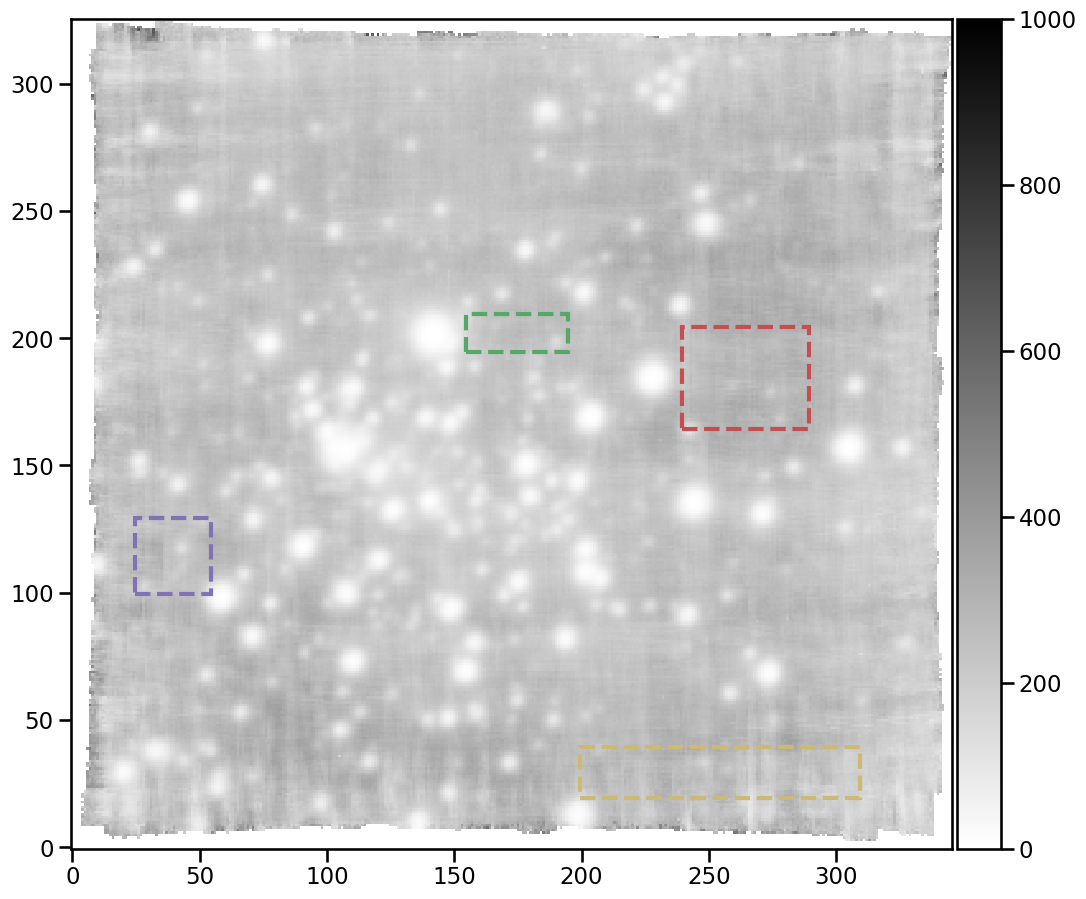

In [18]:
fig, ax = plt.subplots(figsize=(12, 12))
(ewha).plot(
    vmin=0,
    vmax=1000,
    scale="linear",
    cmap="gray_r",
    colorbar="v",
)

for box, c in zip(boxes.values(), "yrmgc"):
    box.plot(
        ax=ax,
        lw=3,
        edgecolor=c,
        linestyle="dashed",
        #        facecolor=(1.0, 1.0, 1.0, 0.4),
        fill=False,
    )

In [19]:
for label, box in boxes.items():
    (yslice, xslice), _ = box.get_overlap_slices(imha.shape)
    ew = np.mean(ewha[yslice, xslice].data.data)
    dew = np.std(ewha[yslice, xslice].data.data)
    print(f"{label}: {ew:.3f} +/- {dew:.3f}")

sw filament: 243.377 +/- 38.587
bow shock: 275.787 +/- 26.617
w filament: 237.484 +/- 33.780
c filament: 230.646 +/- 30.356


### The reddening law

In [20]:
pn.RedCorr().getLaws()

dict_keys(['No correction', 'CCM89', 'CCM89 Bal07', 'CCM89 oD94', 'S79 H83 CCM89', 'K76', 'SM79 Gal', 'G03 LMC', 'MCC99 FM90 LMC', 'F99-like', 'F99', 'F88 F99 LMC', 'Cal00'])

PyNeb does not seem to have anything specifically tailored to the SMC.  The average SMC extinction law is supposedly simply $1/\lambda$.

But, it is possible to get a SMC curve by using the "F99-like" option, which uses the curve of Fitzpatrick & Massa 1990, ApJS, 72, 163. This depends on $R_V$ and 6 other parameters (!!!).  Most of the parameters only affect the UV part of the curve, which does not concern us.

Then, we can use the average values of $R_V$ and the other parameters, which were fit by Gordon:2003l to SMC stars. This is $R_V = 2.74 \pm 0.13$.

So here I compare that SMC curve with $1/\lambda$ and with the Clayton curve for Milky Way (but also adjusted to $R_V = 2.74$):

[(4000.0, 9300.0), (-2.5, 1.0)]

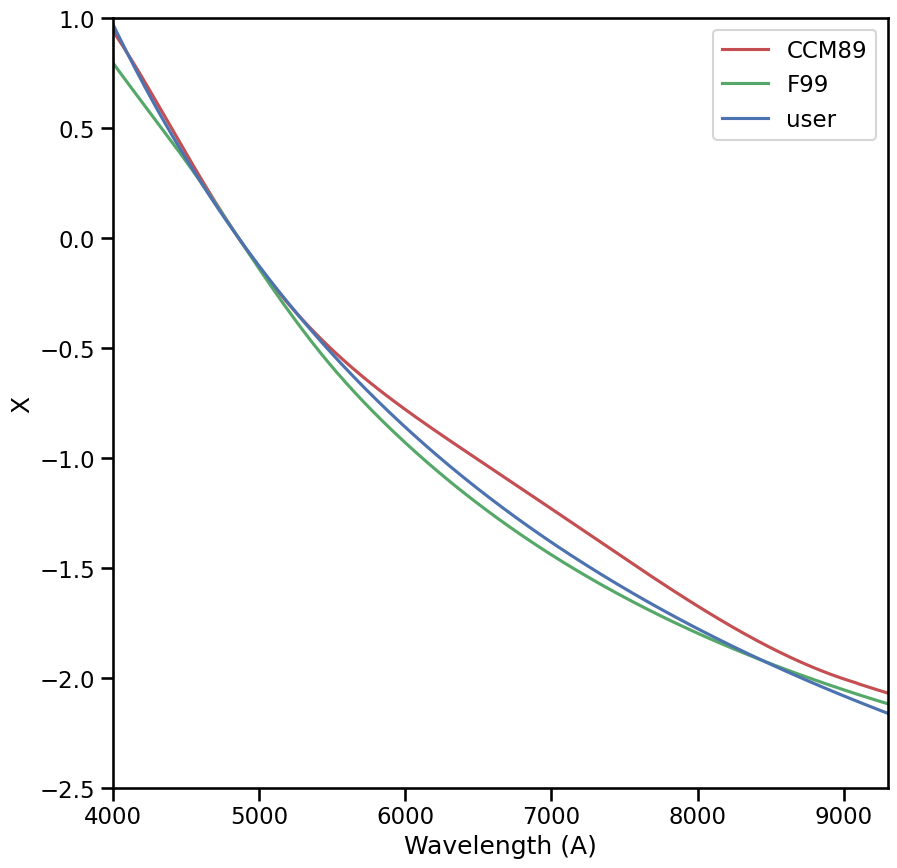

In [21]:
def A_lam(wave):
    return 4861.32 / wave


def my_X(wave, params=[]):
    """A_lam / E(B - V) ~ lam^-1"""
    return A_lam(wave) / (A_lam(4400) - A_lam(5500))


rc = pn.RedCorr()
rc.UserFunction = my_X
rc.R_V = 2.74
rc.FitzParams = [-4.96, 2.26, 0.39, 0.6, 4.6, 1.0]
f, ax = plt.subplots(figsize=(10, 10))
rc.plot(laws=["user", "F99", "CCM89"], ax=ax)

ax.set(
    xlim=[4000, 9300],
    ylim=[-2.5, 1.0],
    #    xlim=[4000, 7000],
    #    ylim=[-1, 1],
)

So the Gordon curve is flatter in the blue, steeper in green, and flatter in red, as compared to $1/\lambda$.

In [22]:
rc = pn.RedCorr()
rc.R_V = 2.74
rc.FitzParams = [-4.96, 2.26, 0.39, 0.6, 4.6, 1.0]
rc.law = "F99"

Test it out for the bow shock region:

In [23]:
rc.setCorr(obs_over_theo=3.123 / R0, wave1=6563.0, wave2=4861.0)
rc.E_BV, rc.cHbeta

(array(0.08918852), 0.11614443544515395)

And for the highest extinction region

In [24]:
rc.setCorr(obs_over_theo=4.165 / R0, wave1=6563.0, wave2=4861.0)
rc.E_BV, rc.cHbeta

(array(0.3412549), 0.44439418598965574)

So $E(B - V)$ varies from about 0.1 to about 0.35. This is similar to what is found for the stars.

### The reddening map

We can now make a map of $E(B - V)$

In [25]:
R = imha / (imhb)
rc.setCorr(obs_over_theo=R.data / R0, wave1=6563.0, wave2=4861.0)
imEBV = R.copy()
imEBV.data = rc.E_BV
imEBV.mask = imha.mask | imhb.mask

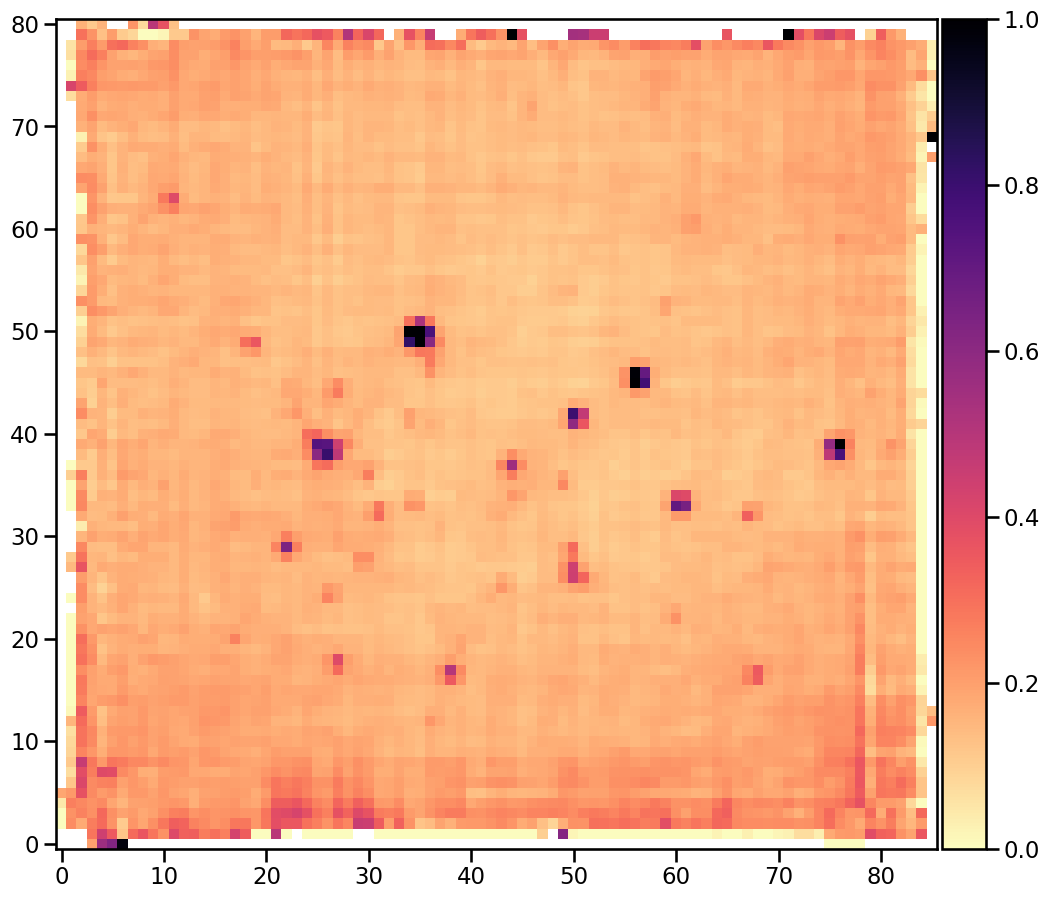

In [26]:
fig, ax = plt.subplots(figsize=(12, 12))
imEBV.rebin(4).plot(
    vmin=0.0,
    vmax=1.0,
    scale="linear",
    cmap="magma_r",
    colorbar="v",
)

Looks like I would expect. Check values in the boxes:

In [27]:
for label, box in boxes.items():
    (yslice, xslice), _ = box.get_overlap_slices(imha.shape)
    ebv = np.median(imEBV[yslice, xslice].data.data)
    print(f"{label}: {ebv:.3f}")

sw filament: 0.210
bow shock: 0.139
w filament: 0.164
c filament: 0.122


These seem the same as before.  But we want to eliminate extreme values.

In [28]:
badpix = (imEBV.data > 1.0) | (imEBV.data < 0.0)
imEBV.mask = imEBV.mask | badpix

Save it to a file:

In [29]:
imEBV.write(str(ROOT / "data/ngc346-ZZ-reddening-E_BV.fits"), savemask="nan")

Lots of regions are affected by the stellar absorption.  There are apparent increases in reddening at the position of each star.  This is not real, but is due to the photospheric absorption having more of an effect on Hb (mainly because the emission line is weaker).

At some point, I am going to have to deal with that. But it is not an issue for the bow shock emission, since this is in an area free of stars.  We should just use the median bow shock reddening of $E(B-V) = 0.139$ so that we don't introduce any extra noise.

<>:8: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:8: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_90684/2657971787.py:8: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  xlabel="Wavelength, $\lambda$, Å",
/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_90684/2657971787.py:9: SyntaxWarning: "\l" is an invalid escape

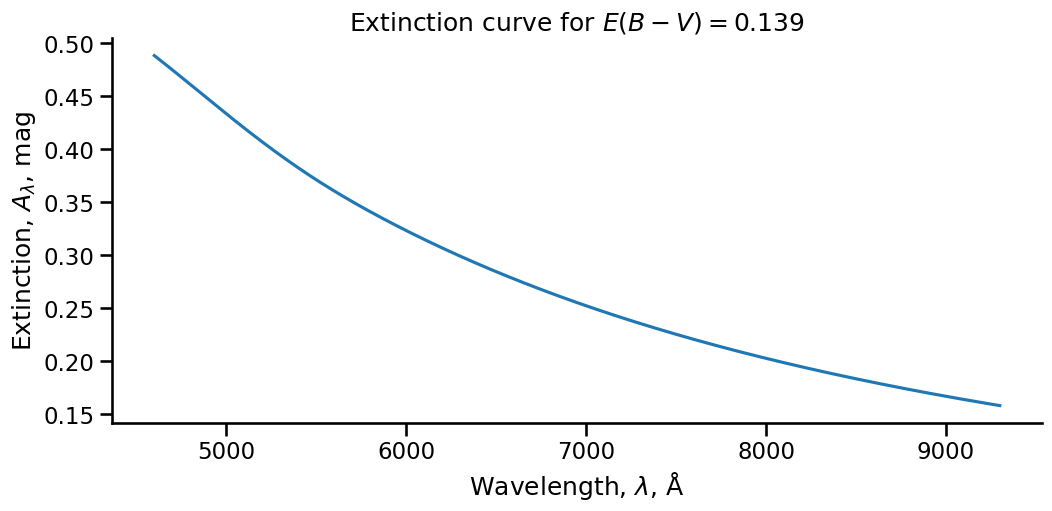

In [30]:
rc.E_BV = 0.139
wavs = np.arange(4600, 9300)
Alam = rc.E_BV * rc.X(wavs)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(wavs, Alam)
ax.set(
    xlabel="Wavelength, $\lambda$, Å",
    ylabel="Extinction, $A_\lambda$, mag",
    title=f"Extinction curve for $E(B - V) = {rc.E_BV:.3f}$",
)
sns.despine()